# Experimentos Multivariados v4 Cloud (Vertex AI)

**Tesis MEC** — 33 DGPs multivariados x T in {25,50,100,200} x R=500
**Verificacion DGP:** cada experimento incluye seccion PASS/FAIL multivariada antes del Monte Carlo
**Horizonte por T:** T=25->H=6 * T=50->H=18 * T=100,200->H=24
**Metricas (per-variable):** Bias, Varianza, RMSE, MAE, CRPS, Cobertura/Amplitud/Winkler 80%-95%
**Metricas (multivariadas conjuntas):** Trace MSFE + avgCRPS marginal — ver Cell 1.5 para justificacion y descartes
**Bloques h:** Corto h=1-6 * Medio h=7-18 * Largo h=19-24
**Logging:** dual stdout + `results/multivariate_vertexai/run_YYYYMMDD_HHMMSS.log`
**Resultados:** `results/multivariate_vertexai/` — si existen se cargan sin re-simular

**Bloques de experimentos:**
- **M-A** (8) — VAR(1) bivariado estacionario, distintos patrones de dependencia
- **M-B** (6) — VAR orden superior y cerca de raiz unitaria
- **M-C** (5) — Dimensionalidad creciente (k=3..6)
- **M-D** (6) — VAR + GARCH diagonal (heteroscedasticidad condicional)
- **M-E** (5) — Cointegracion VECM bivariado rango 1
- **M-F** (3) — VAR con eigenvalores complejos (ciclos endogenos)

**Notas:**
- Modelos por experimento: clasico correcto (VAR/VECM/VAR+GARCH-diag) + Chronos-2 (joint, `ChronosMultivariateModel`).
- `VARDGP` no soporta constante/drift/trend: todos los DGPs asumen media cero.
- `VECMBivariateDGP` solo soporta k=2 rango 1 (extension a rango>=2 o k>=3 fuera de alcance).
- T_list restringido per-experimento para k>=4 (curse of dimensionality).


In [1]:
import os
import warnings
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
warnings.filterwarnings("ignore")

import copy
import logging
import sys
import time
import traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import torch
from IPython.display import display

from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_arch
from statsmodels.tsa.vector_ar.var_model import VAR as SMVAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen

from mectesis.dgp import VARDGP, VARGARCHDiagonalDGP, VECMBivariateDGP
from mectesis.models import (
    VARModel, VECMModel, VARGARCHDiagonalModel,
    ChronosModel, ChronosMultivariateModel,
)
from mectesis.simulation import MultivariateMonteCarloEngine
from mectesis.metrics import trace_msfe, avg_marginal_crps  # noqa: F401 — usadas via engine

# Parametros globales
SEED    = 3649
H_BY_T  = {25: 6, 50: 18, 100: 24, 200: 24}
H_MAX   = 24
R_LIST  = [500]
T_LIST  = [25, 50, 100, 200]
RESULTS = Path("results/multivariate_vertexai")
RESULTS.mkdir(parents=True, exist_ok=True)

# Logging dual: notebook + archivo .log
log_path = RESULTS / f"run_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(message)s",
    datefmt="%H:%M:%S",
    handlers=[
        logging.FileHandler(log_path, encoding="utf-8"),
        logging.StreamHandler(sys.stdout),
    ],
)
log = logging.getLogger().info
log(f"Log en: {log_path}")

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)

device = "cuda" if torch.cuda.is_available() else "cpu"
log(f"Cargando Chronos-2 en {device} (puede tardar ~30 s la primera vez)...")
_chronos_base = ChronosModel(device=device)
chronos_mv    = ChronosMultivariateModel(_chronos_base)
log("Chronos-2 listo.")


21:10:06  Log en: results\multivariate_vertexai\run_20260516_211006.log
21:10:06  Cargando Chronos-2 en cpu (puede tardar ~30 s la primera vez)...
21:10:10  Chronos-2 listo.


---
## Metricas seleccionadas y descartes metodologicos

Esta seccion documenta por que se reportan exactamente dos tablas de metricas
por experimento y por que se descartan alternativas que podrian parecer
naturales. La decision es metodologica y restringe el tipo de afirmaciones
que se pueden hacer en la tesis. Conviene leerla antes de interpretar los
resultados de los bloques M-A..M-F.

### Panel completo

| Tipo            | Per-variable (tabla 1)                                  | Multivariada conjunta (tabla 2) |
|-----------------|---------------------------------------------------------|---------------------------------|
| Puntual         | bias, varianza, MSE, RMSE, MAE                          | **Trace MSFE**                  |
| Probabilistica  | CRPS                                                    | **avgCRPS marginal**            |
| Intervalos      | Cobertura / amplitud / Winkler (80% y 95%)              | —                               |
| Dependencia     | —                                                       | — (no se mide; ver descartes)   |

La tabla 1 ya estaba presente en `experimentos_multivariados.ipynb` original
(7 exps exploratorios). La tabla 2 es nueva y agrega resumenes unicos por
(T, R, Modelo) sin desglose por variable.

### Metricas seleccionadas — definiciones y referencias

**Trace MSFE(h)** — la traza de la matriz de error cuadratico medio del forecast:

$$\\mathrm{Trace\ MSFE}(h) = \\mathrm{tr}\\big(\\mathbb{E}[e_h e_h^{\\top}]\\big) = \\sum_{i=1}^{k} \\mathbb{E}[e_{ih}^2] = \\sum_{i=1}^{k} \\mathrm{MSE}_i(h)$$

donde $e_h = y_{\\text{test}}(h) - \\hat{y}(h) \\in \\mathbb{R}^k$. Es la metrica
puntual multivariada estandar en econometria clasica. Se computa directamente
de la matriz de errores `(n_sim, horizon, k)` del Monte Carlo, sin necesidad
de samples conjuntos. Es matematicamente equivalente a la suma de los MSE
marginales — no agrega informacion estadistica nueva — pero entrega **un
unico numero resumen por (T, Modelo, h)** que es lo que se reporta en libros
de texto de series de tiempo multivariadas.

> Referencias: Lutkepohl (2005), *New Introduction to Multiple Time Series
> Analysis*, Springer, cap. 2; Hamilton (1994), *Time Series Analysis*,
> Princeton University Press, cap. 11.

**avgCRPS(h)** — el promedio del CRPS marginal a traves de las $k$ variables:

$$\\mathrm{avgCRPS}(h) = \\frac{1}{k} \\sum_{i=1}^{k} \\mathrm{CRPS}_i(h)$$

donde $\\mathrm{CRPS}_i(h)$ es el CRPS estandar de la marginal $i$ en el
horizonte $h$. Es una **scoring rule propia** (la propiedad se preserva
bajo combinacion lineal positiva de scoring rules propias; Gneiting &
Raftery 2007, sec. 2). Es la metrica probabilistica multivariada
*default* reportada en zero-shot multivariate forecasting cuando el modelo
solo expone cuantiles marginales (caso de Chronos-2).

> Referencias: Gneiting, T. & Raftery, A.E. (2007). Strictly proper scoring
> rules, prediction, and estimation. *JASA* 102(477), 359–378. Matheson,
> J.E. & Winkler, R.L. (1976). Scoring rules for continuous probability
> distributions. *Management Science* 22(10), 1087–1096.

### Metricas descartadas y por que

#### Energy Score (ES)

$$\\mathrm{ES}(F, y) = \\mathbb{E}_F\\|X - y\\| - \\tfrac{1}{2}\\,\\mathbb{E}_F\\|X - X'\\|$$

Es la generalizacion multivariada propia del CRPS y la metrica conjunta
mas usada en forecasting probabilistico (Gneiting & Raftery 2007).

**Por que se descarta en este contexto:** ES requiere muestras conjuntas
$X \\sim F$ para estimarse. `Chronos2Pipeline` **solo expone
`predict_quantiles`** — no hay API de samples ni argumento `num_samples`
(verificado en el quickstart oficial). La tentacion natural seria pedir
$M$ cuantiles uniformemente espaciados y usarlos como pseudo-ensemble.

El argumento de que esto seria $\\mathcal{O}(1/M)$ insesgado **es correcto
en $d=1$ y falso en $d>1$**, que es justamente donde ES tiene sentido. La
razon: las trayectorias resultantes

$$s_k = \\big(q_{k/(M+1)}(1),\\ q_{k/(M+1)}(2),\\ \\ldots,\\ q_{k/(M+1)}(d)\\big),\\quad k=1,\\ldots,M$$

usan el **mismo nivel de cuantil en todos los lead times**, lo que impone
**copula comonotonica** (correlacion de rango de Spearman = 1 entre cualquier
par de pasos). Esta no es la copula que el modelo realmente induce. El sesgo
es estructural y **no decrece con $M$**: aumentar $M$ densifica las
marginales pero deja la copula fija. Argumento desarrollado siguiendo
Schefzik, Thorarinsdottir & Gneiting (2013).

Soluciones consideradas y descartadas:

1. **Schaake Shuffle / Ensemble Copula Coupling** (Clark et al. 2004;
   Schefzik et al. 2013): inyectar una copula climatologica del DGP como
   template. Metodologicamente correcto pero **borra la senal que distingue
   modelos en M-E (cointegracion) y M-A.2/5/7**: la diferencia entre VAR y
   VECM vive precisamente en la copula del error de forecast (VECM predice
   reversion al equilibrio → errores con dependencia negativa; VAR predice
   separacion → errores con dependencia creciente). Schaake Shuffle inyecta
   la misma copula del DGP a ambos modelos, neutralizando la senal sin
   resolverla. Aniquila la pregunta multivariada conjunta sin contestarla.

2. **Acceder a trayectorias internas del unrolling autorregresivo de
   Chronos-2:** invasivo, fragil ante cambios de version del paquete, y
   no es claro que la copula de esas trayectorias intermedias sea mas
   representativa que la climatologica. No vale el costo de implementacion
   y mantenimiento.

3. **Cambiar a `ChronosPipeline` (T5 generativo original):** si muestrea
   trayectorias conjuntas via sampling autorregresivo de tokens, pero
   tiene un costo computacional 5–250x mayor que Chronos-2 y es un modelo
   distinto. Solo se justificaria si ES/VS fueran el KPI central del
   proyecto, lo cual no es el caso para esta tesis.

#### Variogram Score (VS)

$$\\mathrm{VS}_p(F, y) = \\sum_{i,j} w_{ij}\\,\\big(|y_i - y_j|^p - \\mathbb{E}_F |X_i - X_j|^p\\big)^2$$

Disenado especificamente para medir estructura de dependencia entre
variables (Scheuerer & Hamill 2015).

**Por que se descarta:** padecen los mismos problemas que ES.
$\\mathbb{E}_F |X_i - X_j|^p$ es un momento cruzado entre componentes —
depende de la copula, no de las marginales. Con cuantiles equiespaciados
de Chronos, $|X_i - X_j|$ queda fijado por las marginales bajo copula
comonotonica y el estimador converge al valor **incorrecto**. Schaake
Shuffle padece la misma limitacion conceptual que con ES en este contexto.

#### Multivariate CRPS exacto

Definido como $\\mathbb{E}_F \\|X - y\\|_2$ con norma Euclidea (sin el
termino de simetria). Costo $\\mathcal{O}(n_{\\text{samples}}^2)$ por
simulacion, raras veces se reporta en la practica. ES es el sustituto
estandar y ya fue descartado por la razon anterior.

#### Determinant of MSFE — $\\det(\\mathrm{MSFE}(h))^{1/k}$

"Generalized variance" del error. Si captura covarianzas cruzadas entre
errores y es una metrica puntual conjunta valida sin necesidad de samples.

**Por que se descarta:** rara vez se reporta fuera de literatura clasica
de control optimal. Trace MSFE es la eleccion estandar para resumen
puntual en analisis econometrico. Se documenta como extension opcional
para analisis post-hoc: $\\det(\\mathrm{MSFE})$ se puede calcular sobre los
CSV existentes sin re-correr nada (la informacion de errores conjuntos
queda disponible en `error_mats` durante la ejecucion del engine, y
podria almacenarse explicitamente en futuras versiones).

#### Metricas de copula explicitas

Spearman $\\rho$ entre forecasts, coeficientes de tail dependence,
etc. — quedan fuera del scope de scoring rules propias. Utiles como
analisis diagnostico complementario pero no constituyen una metrica
de calidad predictiva.

### Limitacion declarada explicitamente

La eleccion de Trace MSFE + avgCRPS implica que **no medimos la calidad
de la copula predictiva**. Dos modelos con marginales identicas pero
copulas distintas reciben exactamente los mismos scores en este panel.

**Implicaciones para la redaccion de la tesis:**

✓ Afirmaciones validas con este panel:
- *"Chronos joint produce marginales tan buenas como VAR en M-A.2"*
- *"VECM domina en horizontes largos en la calidad marginal de cada
  serie cointegrada"*
- *"En el bloque M-C (alta dimensionalidad), Chronos joint mantiene
  performance competitivo segun avgCRPS hasta $k=6$"*

✗ Afirmaciones que **NO** se sostienen con este panel:
- *"Chronos joint captura la dependencia cruzada"*
- *"VECM aprende la estructura de cointegracion mejor que VAR en
  terminos de la distribucion conjunta"*
- *"El modelo X tiene mejor calibracion del riesgo agregado de portafolio"*

Para sostener este segundo grupo de afirmaciones haria falta extender el
panel con ES/VS sobre Schaake Shuffle (documentando el supuesto de
copula climatologica) o cambiar a `ChronosPipeline` original (asumiendo
el costo computacional). Ninguna de estas extensiones se incluye en este
notebook.

### Referencias bibliograficas

- Clark, M., Gangopadhyay, S., Hay, L., Rajagopalan, B., & Wilby, R.
  (2004). The Schaake shuffle: a method for reconstructing space-time
  variability in forecasted precipitation and temperature fields.
  *Journal of Hydrometeorology*, 5(1), 243–262.
- Gneiting, T., & Raftery, A.E. (2007). Strictly proper scoring rules,
  prediction, and estimation. *Journal of the American Statistical
  Association*, 102(477), 359–378.
- Hamilton, J.D. (1994). *Time Series Analysis*. Princeton University
  Press, cap. 11.
- Lutkepohl, H. (2005). *New Introduction to Multiple Time Series
  Analysis*. Springer, cap. 2.
- Matheson, J.E., & Winkler, R.L. (1976). Scoring rules for continuous
  probability distributions. *Management Science*, 22(10), 1087–1096.
- Schefzik, R., Thorarinsdottir, T.L., & Gneiting, T. (2013). Uncertainty
  quantification in complex simulation models using ensemble copula
  coupling. *Statistical Science*, 28(4), 616–640.
- Scheuerer, M., & Hamill, T.M. (2015). Variogram-based proper scoring
  rules for probabilistic forecasts of multivariate quantities. *Monthly
  Weather Review*, 143(4), 1321–1334.
- Winkler, R.L. (1972). A decision-theoretic approach to interval
  estimation. *Journal of the American Statistical Association*, 67(337),
  187–191.


In [2]:
# ─── Funciones auxiliares multivariadas ─────────────────────────────────────

def _cache_path(exp_id: str, T: int, R: int) -> Path:
    return RESULTS / f"exp_{exp_id.replace('.', '_')}_T{T}_R{R}.csv"


def _save_results_mv(results: dict, path: Path):
    """Guarda {model: {var_idx: DataFrame}} como CSV con columnas 'model','var'."""
    frames = []
    for mname, var_dict in results.items():
        for var_idx, df in var_dict.items():
            tmp = df.copy()
            tmp.insert(0, "var", var_idx)
            tmp.insert(0, "model", mname)
            frames.append(tmp)
    pd.concat(frames, ignore_index=True).to_csv(path, index=False)


def _load_results_mv(path: Path) -> dict:
    df = pd.read_csv(path)
    results = {}
    for mname, mgrp in df.groupby("model", sort=False):
        results[mname] = {}
        for var_idx, vgrp in mgrp.groupby("var", sort=True):
            results[mname][int(var_idx)] = (
                vgrp.drop(columns=["model", "var"]).reset_index(drop=True)
            )
    return results


def run_exp_mv(dgp, make_models_fn, dgp_params, exp_id,
               T_list=None, R_list=None, H_by_T=None, seed=SEED):
    """
    Corre MC multivariado para todas las combinaciones (T, R).
    T_list/R_list/H_by_T per-experimento sobrescriben los globales.
    """
    T_list = T_list if T_list is not None else T_LIST
    R_list = R_list if R_list is not None else R_LIST
    H_by_T = H_by_T if H_by_T is not None else H_BY_T

    n_runs = len(T_list) * len(R_list)
    combos = ", ".join(
        f"(T={t}, H={H_by_T.get(t, H_MAX)}, R={r})"
        for t in T_list for r in R_list
    )
    log(f"Exp {exp_id}: {n_runs} ejecucion(es) -> {combos}")

    all_results = {}
    for T in T_list:
        h = H_by_T.get(T, H_MAX)
        for R in R_list:
            cache = _cache_path(exp_id, T, R)
            if cache.exists():
                log(f"  T={T} H={h}, R={R}: cargando {cache.name}")
                all_results[(T, R)] = _load_results_mv(cache)
                continue
            log(f"  T={T} H={h}, R={R}: simulando...")
            dgp.rng = np.random.default_rng(seed)
            models = make_models_fn(T)
            engine = MultivariateMonteCarloEngine(dgp, models, seed=seed)
            t0 = time.time()
            results = engine.run_monte_carlo(R, T, h, dgp_params, verbose=False)
            log(f"  T={T} H={h}, R={R}: OK ({time.time()-t0:.0f}s)")
            _save_results_mv(results, cache)
            all_results[(T, R)] = results
    return all_results


# ─── Bloques v3 (Corto / Medio / Largo) ─────────────────────────────────────

BLOCK_DEFS = [("C", 1, 6), ("M", 7, 18), ("L", 19, 24)]
METRICS_V3  = ["bias", "variance", "rmse", "crps"]


def compute_blocks_mv(results_TR: dict) -> dict:
    """Promedios por bloque h por variable: {model: {var: {blk: Series}}}"""
    out = {}
    for mname, var_dict in results_TR.items():
        out[mname] = {}
        for var_idx, df in var_dict.items():
            df_h = df[df["horizon"] != "avg_all"].copy()
            df_h["horizon"] = pd.to_numeric(df_h["horizon"], errors="coerce")
            blks = {}
            for blk, h1, h2 in BLOCK_DEFS:
                mask = (df_h["horizon"] >= h1) & (df_h["horizon"] <= h2)
                blks[blk] = df_h[mask].mean(numeric_only=True)
            out[mname][var_idx] = blks
    return out


def build_grid_table_mv(all_results, classical_name: str, chronos_name: str = "Chronos-2 (joint)",
                         var_names=None):
    """
    Tabla 1 (per-variable) por (T, Variable, Modelo) con metricas por bloque h
    y marcador C/T. Ignora la fila virtual var=-1 (metricas joint, ver tabla 2).
    """
    rows = []
    for (T, R), res_TR in sorted(all_results.items()):
        blk_data = compute_blocks_mv(res_TR)
        var_idx_set = set()
        for var_dict in blk_data.values():
            var_idx_set.update(var_dict.keys())
        var_idx_set = {v for v in var_idx_set if v >= 0}   # excluir joint

        for var_idx in sorted(var_idx_set):
            vname = var_names[var_idx] if var_names else f"Y{var_idx+1}"
            cl_blks = blk_data.get(classical_name, {}).get(var_idx, {})
            ch_blks = blk_data.get(chronos_name, {}).get(var_idx, {})

            for mname, var_blks in blk_data.items():
                if var_idx not in var_blks:
                    continue
                blks = var_blks[var_idx]
                row = {"T": T, "Variable": vname, "Modelo": mname}
                for blk, h1, h2 in BLOCK_DEFS:
                    s = blks.get(blk, pd.Series(dtype=float))
                    for m in METRICS_V3:
                        row[f"{m}_{blk}"] = (
                            round(float(s[m]), 4)
                            if m in s.index and pd.notna(s[m]) else np.nan
                        )
                    cl_s = cl_blks.get(blk, pd.Series(dtype=float))
                    ch_s = ch_blks.get(blk, pd.Series(dtype=float))
                    for m in ["rmse", "crps"]:
                        cv = float(cl_s[m]) if m in cl_s.index and pd.notna(cl_s[m]) else np.nan
                        hv = float(ch_s[m]) if m in ch_s.index and pd.notna(ch_s[m]) else np.nan
                        if np.isnan(cv) or np.isnan(hv):
                            row[f"best_{m}_{blk}"] = np.nan
                        else:
                            row[f"best_{m}_{blk}"] = "C" if cv <= hv else "T"
                rows.append(row)

    df_out = pd.DataFrame(rows).set_index(["T", "Variable", "Modelo"])
    display(df_out.style.format(precision=4, na_rep="—"))


def build_grid_table_mv_joint(all_results, classical_name: str,
                               chronos_name: str = "Chronos-2 (joint)"):
    """
    Tabla 2 (multivariada conjunta) por (T, Modelo) con Trace MSFE y avgCRPS
    promediados por bloque h (C / M / L), mas marcadores C/T por bloque
    indicando que modelo gana (mismo formato que build_grid_table_mv).
    Lee la fila virtual var=-1 que el engine inyecta.
    """
    rows = []
    for (T, R), res_TR in sorted(all_results.items()):
        blk_data = compute_blocks_mv(res_TR)
        cl_blks = blk_data.get(classical_name, {}).get(-1, {})
        ch_blks = blk_data.get(chronos_name, {}).get(-1, {})

        for mname, var_blks in blk_data.items():
            joint = var_blks.get(-1, None)
            if joint is None:
                continue
            row = {"T": T, "Modelo": mname}
            for blk, h1, h2 in BLOCK_DEFS:
                s = joint.get(blk, pd.Series(dtype=float))
                for m in ["trace_msfe", "avg_crps"]:
                    row[f"{m}_{blk}"] = (
                        round(float(s[m]), 4)
                        if m in s.index and pd.notna(s[m]) else np.nan
                    )
                # Marcador C/T: gana clasico (C) si su metrica es <=, sino Chronos (T)
                cl_s = cl_blks.get(blk, pd.Series(dtype=float))
                ch_s = ch_blks.get(blk, pd.Series(dtype=float))
                for m in ["trace_msfe", "avg_crps"]:
                    cv = float(cl_s[m]) if m in cl_s.index and pd.notna(cl_s[m]) else np.nan
                    hv = float(ch_s[m]) if m in ch_s.index and pd.notna(ch_s[m]) else np.nan
                    if np.isnan(cv) or np.isnan(hv):
                        row[f"best_{m}_{blk}"] = np.nan
                    else:
                        row[f"best_{m}_{blk}"] = "C" if cv <= hv else "T"
            rows.append(row)

    if not rows:
        log("  [tabla joint] sin filas — el CSV no contiene metricas joint "
            "(probablemente generado por una version anterior del engine; "
            "borrar y re-ejecutar para incluirlas).")
        return

    df_out = pd.DataFrame(rows).set_index(["T", "Modelo"])
    display(df_out.style.format(precision=4, na_rep="—"))


def plot_simulation_mv(dgp, models, dgp_params, var_names=None,
                        title="", T_vis=100, seed=SEED):
    """Visualiza un path representativo: k subplots verticales."""
    H_vis = H_BY_T.get(T_vis, H_MAX)
    dgp_r = copy.deepcopy(dgp)
    dgp_r.rng = np.random.default_rng(seed + 99991)
    y = dgp_r.simulate(T=T_vis, **dgp_params)
    k = y.shape[1]
    split = T_vis - H_vis
    y_train, y_test = y[:split], y[split:]

    palette = ["steelblue", "darkorange", "seagreen", "purple", "teal", "crimson"]
    fig, axes = plt.subplots(k, 1, figsize=(11, 3.0 * k), squeeze=False)

    for m in models:
        try:
            m.fit(y_train)
        except Exception as e:
            log(f"  [plot] {m.name} fit fallo: {e}")

    x_tr = np.arange(split)
    x_te = np.arange(split, T_vis)

    for j, ax in enumerate(axes[:, 0]):
        vname = var_names[j] if var_names else f"Y{j+1}"
        ax.plot(x_tr, y_train[:, j], color="gray", lw=1.4, alpha=0.85, label="Historico")
        ax.plot(x_te, y_test[:, j], "k--", lw=1.5, label="Observado (test)")
        ax.axvline(split - 0.5, color="black", ls="--", lw=1, alpha=0.5)

        for i, m in enumerate(models):
            try:
                y_hat = m.forecast(H_vis)
                c = palette[i % len(palette)]
                ax.plot(x_te, y_hat[:, j], color=c, lw=1.5, ls="--",
                        marker="s", ms=3, label=m.name)
                if getattr(m, "supports_intervals", False):
                    lo, hi = m.forecast_intervals(H_vis, level=0.80)
                    ax.fill_between(x_te, lo[:, j], hi[:, j], color=c, alpha=0.12)
            except Exception as e:
                log(f"  [plot] {m.name} forecast fallo en var {j}: {e}")

        ax.set(title=f"{vname}", xlabel="t", ylabel=vname)
        ax.legend(fontsize=8)

    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


# ─── Verificacion DGP multivariada ──────────────────────────────────────────

def verify_dgp_mv(label, dgp, dgp_params, checks):
    log(f"{'-'*60}")
    log(f"VERIFICACION DGP: {label}")
    log(f"{'-'*60}")
    dgp_copy = copy.deepcopy(dgp)
    dgp_copy.rng = np.random.default_rng(7777)
    try:
        y_long = dgp_copy.simulate(T=500, **dgp_params)
    except Exception as e:
        log(f"  [FAIL] simulate() lanzo excepcion: {e}")
        return
    n_fail = 0
    for check_name, check_fn in checks:
        try:
            ok, msg = check_fn(y_long, dgp, dgp_params)
        except Exception as e:
            ok, msg = False, f"excepcion inesperada: {e}"
        tag = "PASS" if ok else "FAIL"
        log(f"  [{tag}] {check_name}: {msg}")
        if not ok:
            n_fail += 1
    if n_fail == 0:
        log("  -> TODAS LAS VERIFICACIONES PASARON")
    else:
        log(f"  -> {n_fail} FALLO(S)")


# Helpers individuales
def _companion_eigvals(A_list):
    A_list = [np.asarray(A, float) for A in A_list]
    k = A_list[0].shape[0]
    p = len(A_list)
    C = np.zeros((k * p, k * p))
    C[:k, :] = np.hstack(A_list)
    if p > 1:
        C[k:, :k * (p - 1)] = np.eye(k * (p - 1))
    return np.linalg.eigvals(C)


def chk_var_stability(y, dgp, dgp_params):
    A_list = getattr(dgp, "A_list", None)
    if A_list is None and hasattr(dgp, "A1"):
        A_list = [dgp.A1]
    if A_list is None:
        return True, "no aplica"
    eig = _companion_eigvals(A_list)
    mod_max = float(np.max(np.abs(eig)))
    ok = mod_max < 0.999
    return ok, f"max|lambda companion|={mod_max:.4f} (umbral 0.999)"


def chk_var_near_unit_root(y, dgp, dgp_params):
    """Para M-B.5/6: aceptar 0.95-0.999 sin marcar fail."""
    A_list = getattr(dgp, "A_list", None)
    if A_list is None and hasattr(dgp, "A1"):
        A_list = [dgp.A1]
    if A_list is None:
        return True, "no aplica"
    eig = _companion_eigvals(A_list)
    mod_max = float(np.max(np.abs(eig)))
    ok = mod_max < 0.9999
    return ok, f"max|lambda|={mod_max:.4f} (cerca unit root esperado)"


def chk_sigma_psd(y, dgp, dgp_params):
    Sigma = getattr(dgp, "Sigma", None)
    if Sigma is None:
        return True, "no aplica"
    Sigma = np.asarray(Sigma, float)
    try:
        np.linalg.cholesky(Sigma)
    except np.linalg.LinAlgError as e:
        return False, f"Sigma no es PSD: {e}"
    eigs = np.linalg.eigvalsh(Sigma)
    return float(eigs.min()) > 1e-8, f"min eig(Sigma)={float(eigs.min()):.6f}"


def chk_empirical_finite(y, dgp, dgp_params):
    if not np.all(np.isfinite(y)):
        return False, "y contiene NaN/inf"
    sd = np.std(y, axis=0)
    return bool(np.all(sd < 1e6)), f"std(y)={np.round(sd, 3).tolist()}"


def chk_garch_stationarity(y, dgp, dgp_params):
    alphas = getattr(dgp, "alphas", None)
    betas  = getattr(dgp, "betas", None)
    if alphas is None or betas is None:
        return True, "no aplica"
    s = np.asarray(alphas) + np.asarray(betas)
    ok = bool(np.all(s < 1.0))
    return ok, f"alpha_i+beta_i={np.round(s, 4).tolist()} (todos < 1)"


def chk_arch_lm_mv(y, dgp, dgp_params, nlags=5):
    """ARCH-LM por variable sobre residuos VAR(1)."""
    try:
        res = SMVAR(y).fit(maxlags=1, trend="c")
        resid = res.resid
    except Exception as e:
        return False, f"VAR(1) fit fallo: {e}"
    pvals = []
    for i in range(resid.shape[1]):
        try:
            _, pval, _, _ = het_arch(resid[:, i], nlags=nlags)
            pvals.append(float(pval))
        except Exception:
            pvals.append(np.nan)
    pv_arr = np.array([p for p in pvals if not np.isnan(p)])
    if len(pv_arr) == 0:
        return False, "todos los het_arch fallaron"
    ok = bool(np.all(pv_arr < 0.05))
    return ok, f"p-values ARCH-LM por eq.={np.round(pvals, 4).tolist()} (se espera <0.05)"


def chk_johansen_rank(y, dgp, dgp_params):
    expected_rank = getattr(dgp, "get_theoretical_properties", lambda: {})().get("coint_rank", 1)
    try:
        res = coint_johansen(y, det_order=0, k_ar_diff=1)
    except Exception as e:
        return False, f"Johansen fallo: {e}"
    trace_stats = res.lr1
    cv_95 = res.cvt[:, 1]  # critical values 95%
    # Encontramos el rango estimado: el primer r tal que trace_stat <= cv
    rank_est = 0
    for r in range(len(trace_stats)):
        if trace_stats[r] > cv_95[r]:
            rank_est = r + 1
    ok = rank_est == expected_rank
    return ok, f"rango estimado={rank_est}, esperado={expected_rank}, trace={np.round(trace_stats, 2).tolist()}"


def chk_individual_I1_vecm(y, dgp, dgp_params):
    msgs, ok_all = [], True
    for i in range(y.shape[1]):
        pv_lvl = float(adfuller(y[:, i], autolag="AIC")[1])
        pv_dif = float(adfuller(np.diff(y[:, i]), autolag="AIC")[1])
        ok_i = (pv_lvl > 0.05) and (pv_dif < 0.05)
        ok_all = ok_all and ok_i
        msgs.append(f"Y{i+1}: ADF_lvl={pv_lvl:.3f}, ADF_dif={pv_dif:.3f}")
    return ok_all, " | ".join(msgs)


def chk_coint_combination_I0(y, dgp, dgp_params):
    beta = getattr(dgp, "beta", None)
    if beta is None:
        return True, "no aplica"
    beta = np.asarray(beta, float)
    z = y @ beta
    pv = float(adfuller(z, autolag="AIC")[1])
    return pv < 0.05, f"ADF(beta'Y) p={pv:.4f} (se espera <0.05)"


def chk_fit_classical_mv(y, dgp, dgp_params, model_factory=None):
    """Verifica que el modelo clasico ajusta y forecastea sin NaN."""
    if model_factory is None:
        return True, "no aplica"
    try:
        m = model_factory()
        m.fit(y[:300])
        fc = m.forecast(horizon=6)
        ok = fc.shape == (6, y.shape[1]) and np.all(np.isfinite(fc))
        return ok, f"fit+forecast OK, shape={fc.shape}"
    except Exception as e:
        return False, str(e)


# ── Grupos de checks por familia ────────────────────────────────────────────

CHECKS_VAR = [
    ("Estabilidad VAR (eigenvalores companion)", chk_var_stability),
    ("Sigma PSD",                                chk_sigma_psd),
    ("Salida finita y std razonable",            chk_empirical_finite),
]
CHECKS_VAR_NEAR_UNIT_ROOT = [
    ("Cerca de raiz unitaria (warning OK)",      chk_var_near_unit_root),
    ("Sigma PSD",                                chk_sigma_psd),
    ("Salida finita",                            chk_empirical_finite),
]
CHECKS_VAR_GARCH = [
    ("Estabilidad VAR media",                    chk_var_stability),
    ("Estacionariedad GARCH (alpha+beta<1)",     chk_garch_stationarity),
    ("Efectos ARCH detectables (LM por eq.)",    chk_arch_lm_mv),
    ("Salida finita",                            chk_empirical_finite),
]
CHECKS_VECM = [
    ("Sigma PSD",                                chk_sigma_psd),
    ("Cada serie I(1)",                          chk_individual_I1_vecm),
    ("Combinacion beta'Y es I(0)",               chk_coint_combination_I0),
    ("Rango cointegracion (Johansen)",           chk_johansen_rank),
]


---
## Bloque M-A — VAR(1) bivariado estacionario (8 exps)

Estresa dependencia cruzada y correlacion contemporanea bajo regimen estable.
Variamos A_1 (densidad y signo) y Sigma (correlacion off-diagonal).


### M-A.1 — VAR(1) baja interdependencia

**DGP:** Y_t = A1 Y_{t-1} + eps_t, A1=[[0.5,0.1],[0.1,0.5]], Sigma off=0.3
**Modelos:** VAR(1) + Chronos-2 (joint)
**Hipotesis:** VAR(1) y Chronos-2 deberian dar resultados similares; baseline.


21:10:11  ------------------------------------------------------------
21:10:11  VERIFICACION DGP: M-A.1 -- VAR(1) baja interdependencia
21:10:11  ------------------------------------------------------------
21:10:11    [PASS] Estabilidad VAR (eigenvalores companion): max|lambda companion|=0.6000 (umbral 0.999)
21:10:11    [PASS] Sigma PSD: min eig(Sigma)=0.700000
21:10:11    [PASS] Salida finita y std razonable: std(y)=[1.178, 1.174]
21:10:11    -> TODAS LAS VERIFICACIONES PASARON
21:10:11  Exp M-A.1: 4 ejecucion(es) -> (T=25, H=6, R=500), (T=50, H=18, R=500), (T=100, H=24, R=500), (T=200, H=24, R=500)
21:10:11    T=25 H=6, R=500: cargando exp_M-A_1_T25_R500.csv
21:10:11    T=50 H=18, R=500: cargando exp_M-A_1_T50_R500.csv
21:10:11    T=100 H=24, R=500: cargando exp_M-A_1_T100_R500.csv
21:10:11    T=200 H=24, R=500: cargando exp_M-A_1_T200_R500.csv
21:10:11  
M-A.1 -- VAR(1) baja interdependencia



--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---


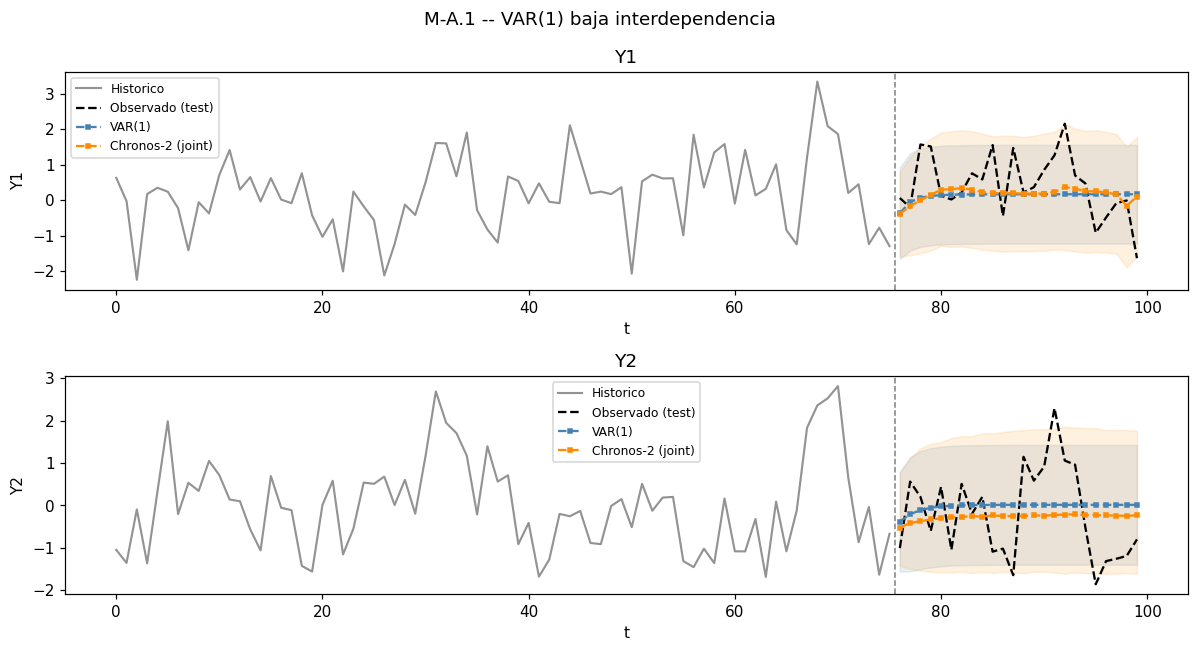

In [3]:
try:
    # M-A.1 -- VAR(1) baja interdependencia
    A_list = [[[0.5,0.1],[0.1,0.5]]]
    Sigma  = [[1.0,0.3],[0.3,1.0]]
    dgp = VARDGP(seed=SEED, A_list=A_list, Sigma=Sigma)
    make_cl = lambda T, lags=1: VARModel(lags=lags)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-A.1 -- VAR(1) baja interdependencia", dgp, {}, CHECKS_VAR)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-A.1")
    log("\n" + "="*60 + "\nM-A.1 -- VAR(1) baja interdependencia\n" + "="*60)
    build_grid_table_mv(res, classical_name="VAR(1)", var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VAR(1)")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2"], title="M-A.1 -- VAR(1) baja interdependencia")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-A.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### M-A.2 — VAR(1) alta interdependencia

**DGP:** A1=[[0.4,0.4],[0.4,0.4]] (todos los acoplamientos iguales)
**Modelos:** VAR(1) + Chronos-2 (joint)
**Hipotesis:** Ventaja pronunciada del modelado conjunto; Chronos joint debe capturar la dependencia.


In [ ]:
try:
    # M-A.2 -- VAR(1) alta interdependencia
    A_list = [[[0.4,0.4],[0.4,0.4]]]
    Sigma  = [[1.0,0.3],[0.3,1.0]]
    dgp = VARDGP(seed=SEED, A_list=A_list, Sigma=Sigma)
    make_cl = lambda T, lags=1: VARModel(lags=lags)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-A.2 -- VAR(1) alta interdependencia", dgp, {}, CHECKS_VAR)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-A.2")
    log("\n" + "="*60 + "\nM-A.2 -- VAR(1) alta interdependencia\n" + "="*60)
    build_grid_table_mv(res, classical_name="VAR(1)", var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VAR(1)")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2"], title="M-A.2 -- VAR(1) alta interdependencia")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-A.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### M-A.3 — Persistencias asimetricas sin acople

**DGP:** A1 diagonal asimetrica, Sigma=I (sin correlacion)
**Modelos:** VAR(1) + Chronos-2 (joint)
**Hipotesis:** Equivale a dos AR(1) independientes; Chronos joint no deberia mejorar sobre VAR.


In [ ]:
try:
    # M-A.3 -- Persistencias asimetricas sin acople
    A_list = [[[0.7,0.0],[0.0,0.3]]]
    Sigma  = [[1.0,0.0],[0.0,1.0]]
    dgp = VARDGP(seed=SEED, A_list=A_list, Sigma=Sigma)
    make_cl = lambda T, lags=1: VARModel(lags=lags)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-A.3 -- Persistencias asimetricas sin acople", dgp, {}, CHECKS_VAR)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-A.3")
    log("\n" + "="*60 + "\nM-A.3 -- Persistencias asimetricas sin acople\n" + "="*60)
    build_grid_table_mv(res, classical_name="VAR(1)", var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VAR(1)")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2"], title="M-A.3 -- Persistencias asimetricas sin acople")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-A.3 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### M-A.4 — Causalidad unidireccional Y1->Y2

**DGP:** A1 triangular superior con acople en (1,2)
**Modelos:** VAR(1) + Chronos-2 (joint)
**Hipotesis:** VAR debe capturar la causalidad; Chronos joint puede o no detectarla con T limitado.


In [ ]:
try:
    # M-A.4 -- Causalidad unidireccional Y1->Y2
    A_list = [[[0.5,0.3],[0.0,0.4]]]
    Sigma  = [[1.0,0.2],[0.2,1.0]]
    dgp = VARDGP(seed=SEED, A_list=A_list, Sigma=Sigma)
    make_cl = lambda T, lags=1: VARModel(lags=lags)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-A.4 -- Causalidad unidireccional Y1->Y2", dgp, {}, CHECKS_VAR)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-A.4")
    log("\n" + "="*60 + "\nM-A.4 -- Causalidad unidireccional Y1->Y2\n" + "="*60)
    build_grid_table_mv(res, classical_name="VAR(1)", var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VAR(1)")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2"], title="M-A.4 -- Causalidad unidireccional Y1->Y2")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-A.4 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### M-A.5 — Off-diagonal y Sigma negativos

**DGP:** A1 con signos negativos, Sigma con correlacion negativa
**Modelos:** VAR(1) + Chronos-2 (joint)
**Hipotesis:** Estresa el manejo de correlaciones negativas en ambas dinamicas.


In [ ]:
try:
    # M-A.5 -- Off-diagonal y Sigma negativos
    A_list = [[[0.6,-0.3],[-0.3,0.6]]]
    Sigma  = [[1.0,-0.4],[-0.4,1.0]]
    dgp = VARDGP(seed=SEED, A_list=A_list, Sigma=Sigma)
    make_cl = lambda T, lags=1: VARModel(lags=lags)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-A.5 -- Off-diagonal y Sigma negativos", dgp, {}, CHECKS_VAR)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-A.5")
    log("\n" + "="*60 + "\nM-A.5 -- Off-diagonal y Sigma negativos\n" + "="*60)
    build_grid_table_mv(res, classical_name="VAR(1)", var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VAR(1)")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2"], title="M-A.5 -- Off-diagonal y Sigma negativos")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-A.5 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### M-A.6 — Persistencia baja (cercano a ruido blanco)

**DGP:** A1 con eigenvalores chicos, Sigma casi diagonal
**Modelos:** VAR(1) + Chronos-2 (joint)
**Hipotesis:** Series casi i.i.d.; ambos modelos tendran sesgo bajo pero varianza similar.


In [ ]:
try:
    # M-A.6 -- Persistencia baja (cercano a ruido blanco)
    A_list = [[[0.2,0.1],[0.1,0.2]]]
    Sigma  = [[1.0,0.1],[0.1,1.0]]
    dgp = VARDGP(seed=SEED, A_list=A_list, Sigma=Sigma)
    make_cl = lambda T, lags=1: VARModel(lags=lags)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-A.6 -- Persistencia baja (cercano a ruido blanco)", dgp, {}, CHECKS_VAR)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-A.6")
    log("\n" + "="*60 + "\nM-A.6 -- Persistencia baja (cercano a ruido blanco)\n" + "="*60)
    build_grid_table_mv(res, classical_name="VAR(1)", var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VAR(1)")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2"], title="M-A.6 -- Persistencia baja (cercano a ruido blanco)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-A.6 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### M-A.7 — Sigma contemporanea fuerte

**DGP:** A1 baseline, Sigma off=0.7 (alta correlacion contemporanea)
**Modelos:** VAR(1) + Chronos-2 (joint)
**Hipotesis:** Test de si Chronos joint aprovecha la correlacion contemporanea.


In [ ]:
try:
    # M-A.7 -- Sigma contemporanea fuerte
    A_list = [[[0.5,0.1],[0.1,0.5]]]
    Sigma  = [[1.0,0.7],[0.7,1.0]]
    dgp = VARDGP(seed=SEED, A_list=A_list, Sigma=Sigma)
    make_cl = lambda T, lags=1: VARModel(lags=lags)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-A.7 -- Sigma contemporanea fuerte", dgp, {}, CHECKS_VAR)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-A.7")
    log("\n" + "="*60 + "\nM-A.7 -- Sigma contemporanea fuerte\n" + "="*60)
    build_grid_table_mv(res, classical_name="VAR(1)", var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VAR(1)")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2"], title="M-A.7 -- Sigma contemporanea fuerte")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-A.7 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### M-A.8 — Sigma=I (sin acople contemporaneo)

**DGP:** A1 baseline, Sigma=I
**Modelos:** VAR(1) + Chronos-2 (joint)
**Hipotesis:** Aislamos el efecto de la dinamica cruzada; Sigma no contribuye.


In [ ]:
try:
    # M-A.8 -- Sigma=I (sin acople contemporaneo)
    A_list = [[[0.5,0.1],[0.1,0.5]]]
    Sigma  = [[1.0,0.0],[0.0,1.0]]
    dgp = VARDGP(seed=SEED, A_list=A_list, Sigma=Sigma)
    make_cl = lambda T, lags=1: VARModel(lags=lags)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-A.8 -- Sigma=I (sin acople contemporaneo)", dgp, {}, CHECKS_VAR)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-A.8")
    log("\n" + "="*60 + "\nM-A.8 -- Sigma=I (sin acople contemporaneo)\n" + "="*60)
    build_grid_table_mv(res, classical_name="VAR(1)", var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VAR(1)")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2"], title="M-A.8 -- Sigma=I (sin acople contemporaneo)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-A.8 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


---
## Bloque M-B — VAR orden superior y cerca-unit-root (6 exps)

Memoria larga (p>=2) y eigenvalores cerca del circulo unitario.
T_list restringido para M-B.5/6 (estimacion inestable con T=25).


### M-B.1 — VAR(2) baseline

**DGP:** Y_t = A1 Y_{t-1} + A2 Y_{t-2} + eps_t
**Modelos:** VAR(2) + Chronos-2 (joint)
**Hipotesis:** VAR(2) debe dominar; Chronos puede capturar lag 2 con contexto largo.  
**T_list:** todos


In [ ]:
try:
    # M-B.1 -- VAR(2) baseline
    A_list = [[[0.5,0.2],[0.1,0.4]], [[0.1,0.0],[0.0,0.1]]]
    Sigma  = [[1.0,0.3],[0.3,1.0]]
    dgp = VARDGP(seed=SEED, A_list=A_list, Sigma=Sigma)
    make_cl = lambda T, lags=2: VARModel(lags=lags)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-B.1 -- VAR(2) baseline", dgp, {}, CHECKS_VAR)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-B.1")
    log("\n" + "="*60 + "\nM-B.1 -- VAR(2) baseline\n" + "="*60)
    build_grid_table_mv(res, classical_name="VAR(2)", var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VAR(2)")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2"], title="M-B.1 -- VAR(2) baseline")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-B.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### M-B.2 — VAR(2) cruzadas en lag 2

**DGP:** A1 diagonal, A2 con acople cruzado
**Modelos:** VAR(2) + Chronos-2 (joint)
**Hipotesis:** Dinamica cruzada solo en lag 2; test del horizonte temporal de Chronos.  
**T_list:** todos


In [ ]:
try:
    # M-B.2 -- VAR(2) cruzadas en lag 2
    A_list = [[[0.4,0.0],[0.0,0.4]], [[0.2,0.1],[0.1,0.2]]]
    Sigma  = [[1.0,0.3],[0.3,1.0]]
    dgp = VARDGP(seed=SEED, A_list=A_list, Sigma=Sigma)
    make_cl = lambda T, lags=2: VARModel(lags=lags)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-B.2 -- VAR(2) cruzadas en lag 2", dgp, {}, CHECKS_VAR)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-B.2")
    log("\n" + "="*60 + "\nM-B.2 -- VAR(2) cruzadas en lag 2\n" + "="*60)
    build_grid_table_mv(res, classical_name="VAR(2)", var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VAR(2)")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2"], title="M-B.2 -- VAR(2) cruzadas en lag 2")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-B.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### M-B.3 — VAR(3) decaimiento geometrico

**DGP:** A_l diagonales con magnitudes 0.3, 0.2, 0.1 (decay geometrico)
**Modelos:** VAR(3) + Chronos-2 (joint)
**Hipotesis:** Memoria larga sin acople cruzado; test orden.  
**T_list:** todos


In [ ]:
try:
    # M-B.3 -- VAR(3) decaimiento geometrico
    A_list = [[[0.3,0.0],[0.0,0.3]], [[0.2,0.0],[0.0,0.2]], [[0.1,0.0],[0.0,0.1]]]
    Sigma  = [[1.0,0.2],[0.2,1.0]]
    dgp = VARDGP(seed=SEED, A_list=A_list, Sigma=Sigma)
    make_cl = lambda T, lags=3: VARModel(lags=lags)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-B.3 -- VAR(3) decaimiento geometrico", dgp, {}, CHECKS_VAR)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-B.3")
    log("\n" + "="*60 + "\nM-B.3 -- VAR(3) decaimiento geometrico\n" + "="*60)
    build_grid_table_mv(res, classical_name="VAR(3)", var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VAR(3)")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2"], title="M-B.3 -- VAR(3) decaimiento geometrico")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-B.3 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### M-B.4 — VAR(4) memoria larga

**DGP:** 4 lags con decay; total persistencia 0.7
**Modelos:** VAR(4) + Chronos-2 (joint)
**Hipotesis:** Test extremo de orden; VAR(4) con T=25 fallara.  
**T_list:** todos


In [ ]:
try:
    # M-B.4 -- VAR(4) memoria larga
    A_list = [[[0.25,0.0],[0.0,0.25]], [[0.2,0.0],[0.0,0.2]], [[0.15,0.0],[0.0,0.15]], [[0.1,0.0],[0.0,0.1]]]
    Sigma  = [[1.0,0.2],[0.2,1.0]]
    dgp = VARDGP(seed=SEED, A_list=A_list, Sigma=Sigma)
    make_cl = lambda T, lags=4: VARModel(lags=lags)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-B.4 -- VAR(4) memoria larga", dgp, {}, CHECKS_VAR)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-B.4")
    log("\n" + "="*60 + "\nM-B.4 -- VAR(4) memoria larga\n" + "="*60)
    build_grid_table_mv(res, classical_name="VAR(4)", var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VAR(4)")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2"], title="M-B.4 -- VAR(4) memoria larga")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-B.4 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### M-B.5 — VAR(1) cerca unit root

**DGP:** A1 cuasi-identidad; eigenvalores ~0.95
**Modelos:** VAR(1) + Chronos-2 (joint)
**Hipotesis:** Casi-RW bivariado; misspecification de estacionariedad.  
**T_list:** [50, 100, 200]


In [ ]:
try:
    # M-B.5 -- VAR(1) cerca unit root
    A_list = [[[0.95,0.02],[0.02,0.93]]]
    Sigma  = [[1.0,0.3],[0.3,1.0]]
    dgp = VARDGP(seed=SEED, A_list=A_list, Sigma=Sigma)
    make_cl = lambda T, lags=1: VARModel(lags=lags)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-B.5 -- VAR(1) cerca unit root", dgp, {}, CHECKS_VAR_NEAR_UNIT_ROOT)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-B.5", T_list=[50, 100, 200])
    log("\n" + "="*60 + "\nM-B.5 -- VAR(1) cerca unit root\n" + "="*60)
    build_grid_table_mv(res, classical_name="VAR(1)", var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VAR(1)")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2"], title="M-B.5 -- VAR(1) cerca unit root")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-B.5 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### M-B.6 — VAR(2) cerca unit root

**DGP:** Companion eigenvalor maximo ~0.97
**Modelos:** VAR(2) + Chronos-2 (joint)
**Hipotesis:** Persistencia alta + orden alto; estimacion VAR puede ser ruidosa.  
**T_list:** [50, 100, 200]


In [ ]:
try:
    # M-B.6 -- VAR(2) cerca unit root
    A_list = [[[0.6,0.1],[0.1,0.6]], [[0.35,0.0],[0.0,0.33]]]
    Sigma  = [[1.0,0.3],[0.3,1.0]]
    dgp = VARDGP(seed=SEED, A_list=A_list, Sigma=Sigma)
    make_cl = lambda T, lags=2: VARModel(lags=lags)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-B.6 -- VAR(2) cerca unit root", dgp, {}, CHECKS_VAR_NEAR_UNIT_ROOT)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-B.6", T_list=[50, 100, 200])
    log("\n" + "="*60 + "\nM-B.6 -- VAR(2) cerca unit root\n" + "="*60)
    build_grid_table_mv(res, classical_name="VAR(2)", var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VAR(2)")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2"], title="M-B.6 -- VAR(2) cerca unit root")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-B.6 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


---
## Bloque M-C — Dimensionalidad creciente (5 exps)

Maldicion de dimensionalidad para VAR vs. transferencia de Chronos.
T_list per-experimento segun grados de libertad (regla T_train >= 4*(k*p+1)).


### M-C.1 — VAR(1) k=3 tridiagonal

**DGP:** k=3, A1 tridiagonal d=0.5/o=0.1, Sigma tridiagonal off=0.2
**Modelos:** VAR(1) + Chronos-2 (joint)
**Hipotesis:** Baseline 3-variado; T=25 viable (k*p+1=4).  
**T_list:** todos


In [ ]:
try:
    # M-C.1 -- VAR(1) k=3 tridiagonal
    A_list = [[[0.5, 0.1, 0.0], [0.1, 0.5, 0.1], [0.0, 0.1, 0.5]]]
    Sigma  = [[1.0, 0.2, 0.0], [0.2, 1.0, 0.2], [0.0, 0.2, 1.0]]
    dgp = VARDGP(seed=SEED, A_list=A_list, Sigma=Sigma)
    make_cl = lambda T, lags=1: VARModel(lags=lags)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-C.1 -- VAR(1) k=3 tridiagonal", dgp, {}, CHECKS_VAR)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-C.1")
    log("\n" + "="*60 + "\nM-C.1 -- VAR(1) k=3 tridiagonal\n" + "="*60)
    build_grid_table_mv(res, classical_name="VAR(1)", var_names=["Y1", "Y2", "Y3"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VAR(1)")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2", "Y3"], title="M-C.1 -- VAR(1) k=3 tridiagonal")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-C.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### M-C.2 — VAR(1) k=4 tridiagonal

**DGP:** k=4, A1 tridiagonal d=0.4/o=0.1
**Modelos:** VAR(1) + Chronos-2 (joint)
**Hipotesis:** Excluye T=25 (T_train=19 < 4*5=20).  
**T_list:** [50, 100, 200]


In [ ]:
try:
    # M-C.2 -- VAR(1) k=4 tridiagonal
    A_list = [[[0.4, 0.1, 0.0, 0.0], [0.1, 0.4, 0.1, 0.0], [0.0, 0.1, 0.4, 0.1], [0.0, 0.0, 0.1, 0.4]]]
    Sigma  = [[1.0, 0.2, 0.0, 0.0], [0.2, 1.0, 0.2, 0.0], [0.0, 0.2, 1.0, 0.2], [0.0, 0.0, 0.2, 1.0]]
    dgp = VARDGP(seed=SEED, A_list=A_list, Sigma=Sigma)
    make_cl = lambda T, lags=1: VARModel(lags=lags)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-C.2 -- VAR(1) k=4 tridiagonal", dgp, {}, CHECKS_VAR)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-C.2", T_list=[50, 100, 200])
    log("\n" + "="*60 + "\nM-C.2 -- VAR(1) k=4 tridiagonal\n" + "="*60)
    build_grid_table_mv(res, classical_name="VAR(1)", var_names=["Y1", "Y2", "Y3", "Y4"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VAR(1)")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2", "Y3", "Y4"], title="M-C.2 -- VAR(1) k=4 tridiagonal")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-C.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### M-C.3 — VAR(1) k=5 tridiagonal

**DGP:** k=5, A1 tridiagonal d=0.3/o=0.05
**Modelos:** VAR(1) + Chronos-2 (joint)
**Hipotesis:** T_train minimo 44 (T=50).  
**T_list:** [50, 100, 200]


In [ ]:
try:
    # M-C.3 -- VAR(1) k=5 tridiagonal
    A_list = [[[0.3, 0.05, 0.0, 0.0, 0.0], [0.05, 0.3, 0.05, 0.0, 0.0], [0.0, 0.05, 0.3, 0.05, 0.0], [0.0, 0.0, 0.05, 0.3, 0.05], [0.0, 0.0, 0.0, 0.05, 0.3]]]
    Sigma  = [[1.0, 0.1, 0.0, 0.0, 0.0], [0.1, 1.0, 0.1, 0.0, 0.0], [0.0, 0.1, 1.0, 0.1, 0.0], [0.0, 0.0, 0.1, 1.0, 0.1], [0.0, 0.0, 0.0, 0.1, 1.0]]
    dgp = VARDGP(seed=SEED, A_list=A_list, Sigma=Sigma)
    make_cl = lambda T, lags=1: VARModel(lags=lags)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-C.3 -- VAR(1) k=5 tridiagonal", dgp, {}, CHECKS_VAR)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-C.3", T_list=[50, 100, 200])
    log("\n" + "="*60 + "\nM-C.3 -- VAR(1) k=5 tridiagonal\n" + "="*60)
    build_grid_table_mv(res, classical_name="VAR(1)", var_names=["Y1", "Y2", "Y3", "Y4", "Y5"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VAR(1)")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2", "Y3", "Y4", "Y5"], title="M-C.3 -- VAR(1) k=5 tridiagonal")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-C.3 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### M-C.4 — VAR(1) k=5 matriz densa

**DGP:** k=5, A1 densa: 0.3 diag + 0.05 off-diagonal (todos correlacionados)
**Modelos:** VAR(1) + Chronos-2 (joint)
**Hipotesis:** Densa requiere mas T para estimar k^2=25 parametros.  
**T_list:** [100, 200]


In [ ]:
try:
    # M-C.4 -- VAR(1) k=5 matriz densa
    A_list = [[[0.3, 0.05, 0.05, 0.05, 0.05], [0.05, 0.3, 0.05, 0.05, 0.05], [0.05, 0.05, 0.3, 0.05, 0.05], [0.05, 0.05, 0.05, 0.3, 0.05], [0.05, 0.05, 0.05, 0.05, 0.3]]]
    Sigma  = [[1.0, 0.1, 0.0, 0.0, 0.0], [0.1, 1.0, 0.1, 0.0, 0.0], [0.0, 0.1, 1.0, 0.1, 0.0], [0.0, 0.0, 0.1, 1.0, 0.1], [0.0, 0.0, 0.0, 0.1, 1.0]]
    dgp = VARDGP(seed=SEED, A_list=A_list, Sigma=Sigma)
    make_cl = lambda T, lags=1: VARModel(lags=lags)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-C.4 -- VAR(1) k=5 matriz densa", dgp, {}, CHECKS_VAR)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-C.4", T_list=[100, 200])
    log("\n" + "="*60 + "\nM-C.4 -- VAR(1) k=5 matriz densa\n" + "="*60)
    build_grid_table_mv(res, classical_name="VAR(1)", var_names=["Y1", "Y2", "Y3", "Y4", "Y5"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VAR(1)")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2", "Y3", "Y4", "Y5"], title="M-C.4 -- VAR(1) k=5 matriz densa")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-C.4 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### M-C.5 — VAR(1) k=6 tridiagonal

**DGP:** k=6, A1 tridiagonal d=0.3/o=0.05
**Modelos:** VAR(1) + Chronos-2 (joint)
**Hipotesis:** Limite superior; Chronos joint cuesta ~12 min/run.  
**T_list:** [100, 200]


In [ ]:
try:
    # M-C.5 -- VAR(1) k=6 tridiagonal
    A_list = [[[0.3, 0.05, 0.0, 0.0, 0.0, 0.0], [0.05, 0.3, 0.05, 0.0, 0.0, 0.0], [0.0, 0.05, 0.3, 0.05, 0.0, 0.0], [0.0, 0.0, 0.05, 0.3, 0.05, 0.0], [0.0, 0.0, 0.0, 0.05, 0.3, 0.05], [0.0, 0.0, 0.0, 0.0, 0.05, 0.3]]]
    Sigma  = [[1.0, 0.1, 0.0, 0.0, 0.0, 0.0], [0.1, 1.0, 0.1, 0.0, 0.0, 0.0], [0.0, 0.1, 1.0, 0.1, 0.0, 0.0], [0.0, 0.0, 0.1, 1.0, 0.1, 0.0], [0.0, 0.0, 0.0, 0.1, 1.0, 0.1], [0.0, 0.0, 0.0, 0.0, 0.1, 1.0]]
    dgp = VARDGP(seed=SEED, A_list=A_list, Sigma=Sigma)
    make_cl = lambda T, lags=1: VARModel(lags=lags)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-C.5 -- VAR(1) k=6 tridiagonal", dgp, {}, CHECKS_VAR)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-C.5", T_list=[100, 200])
    log("\n" + "="*60 + "\nM-C.5 -- VAR(1) k=6 tridiagonal\n" + "="*60)
    build_grid_table_mv(res, classical_name="VAR(1)", var_names=["Y1", "Y2", "Y3", "Y4", "Y5", "Y6"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VAR(1)")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2", "Y3", "Y4", "Y5", "Y6"], title="M-C.5 -- VAR(1) k=6 tridiagonal")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-C.5 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


---
## Bloque M-D — VAR + GARCH diagonal (6 exps)

Calibracion de intervalos bajo volatilidad temporal.
Cada ecuacion sigue GARCH(1,1) sobre los residuos VAR(1).


### M-D.1 — VAR(1) + GARCH baseline

**DGP:** A1 baja interdep, alpha=(0.1,0.15), beta=(0.8,0.75)
**Modelos:** VAR(1)+GARCH-diag + Chronos-2 (joint)
**Hipotesis:** Persistencia GARCH ~0.9; baseline (equivalente al 2.6 original).


In [ ]:
try:
    # M-D.1 -- VAR(1) + GARCH baseline
    A1 = [[0.5,0.1],[0.1,0.5]]
    dgp = VARGARCHDiagonalDGP(seed=SEED, A1=A1, omegas=[0.1, 0.1],
                              alphas=[0.1, 0.15], betas=[0.8, 0.75])
    make_cl = lambda T: VARGARCHDiagonalModel(seed=SEED)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-D.1 -- VAR(1) + GARCH baseline", dgp, {}, CHECKS_VAR_GARCH)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-D.1")
    log("\n" + "="*60 + "\nM-D.1 -- VAR(1) + GARCH baseline\n" + "="*60)
    build_grid_table_mv(res, classical_name="VAR(1)+GARCH-diag", var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VAR(1)+GARCH-diag")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2"], title="M-D.1 -- VAR(1) + GARCH baseline")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-D.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### M-D.2 — GARCH reactivo

**DGP:** alpha=0.3 (mas reactivo a shocks)
**Modelos:** VAR(1)+GARCH-diag + Chronos-2 (joint)
**Hipotesis:** Volatilidad mas espasmodica; test calibracion intervalos.


In [ ]:
try:
    # M-D.2 -- GARCH reactivo
    A1 = [[0.5,0.1],[0.1,0.5]]
    dgp = VARGARCHDiagonalDGP(seed=SEED, A1=A1, omegas=[0.1, 0.1],
                              alphas=[0.3, 0.3], betas=[0.6, 0.6])
    make_cl = lambda T: VARGARCHDiagonalModel(seed=SEED)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-D.2 -- GARCH reactivo", dgp, {}, CHECKS_VAR_GARCH)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-D.2")
    log("\n" + "="*60 + "\nM-D.2 -- GARCH reactivo\n" + "="*60)
    build_grid_table_mv(res, classical_name="VAR(1)+GARCH-diag", var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VAR(1)+GARCH-diag")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2"], title="M-D.2 -- GARCH reactivo")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-D.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### M-D.3 — Casi IGARCH

**DGP:** alpha+beta=0.95 (varianza muy persistente)
**Modelos:** VAR(1)+GARCH-diag + Chronos-2 (joint)
**Hipotesis:** Memoria larga en volatilidad; estresar la estimacion.


In [ ]:
try:
    # M-D.3 -- Casi IGARCH
    A1 = [[0.5,0.1],[0.1,0.5]]
    dgp = VARGARCHDiagonalDGP(seed=SEED, A1=A1, omegas=[0.05, 0.05],
                              alphas=[0.05, 0.05], betas=[0.9, 0.9])
    make_cl = lambda T: VARGARCHDiagonalModel(seed=SEED)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-D.3 -- Casi IGARCH", dgp, {}, CHECKS_VAR_GARCH)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-D.3")
    log("\n" + "="*60 + "\nM-D.3 -- Casi IGARCH\n" + "="*60)
    build_grid_table_mv(res, classical_name="VAR(1)+GARCH-diag", var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VAR(1)+GARCH-diag")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2"], title="M-D.3 -- Casi IGARCH")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-D.3 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### M-D.4 — Mean persistente + GARCH estandar

**DGP:** A1 asimetrica con persistencia alta en Y1
**Modelos:** VAR(1)+GARCH-diag + Chronos-2 (joint)
**Hipotesis:** Test interaccion entre persistencia media y volatilidad.


In [ ]:
try:
    # M-D.4 -- Mean persistente + GARCH estandar
    A1 = [[0.7,0.05],[0.05,0.3]]
    dgp = VARGARCHDiagonalDGP(seed=SEED, A1=A1, omegas=[0.1, 0.1],
                              alphas=[0.1, 0.1], betas=[0.8, 0.8])
    make_cl = lambda T: VARGARCHDiagonalModel(seed=SEED)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-D.4 -- Mean persistente + GARCH estandar", dgp, {}, CHECKS_VAR_GARCH)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-D.4")
    log("\n" + "="*60 + "\nM-D.4 -- Mean persistente + GARCH estandar\n" + "="*60)
    build_grid_table_mv(res, classical_name="VAR(1)+GARCH-diag", var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VAR(1)+GARCH-diag")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2"], title="M-D.4 -- Mean persistente + GARCH estandar")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-D.4 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### M-D.5 — GARCH asimetrico entre ecuaciones

**DGP:** eq.1: alpha=0.2,beta=0.5 (reactivo); eq.2: alpha=0.05,beta=0.9 (persistente)
**Modelos:** VAR(1)+GARCH-diag + Chronos-2 (joint)
**Hipotesis:** Heterogeneidad fuerte entre variables; VAR+GARCH-diag debe capturarlo.


In [ ]:
try:
    # M-D.5 -- GARCH asimetrico entre ecuaciones
    A1 = [[0.3,0.2],[0.2,0.3]]
    dgp = VARGARCHDiagonalDGP(seed=SEED, A1=A1, omegas=[0.1, 0.1],
                              alphas=[0.2, 0.05], betas=[0.5, 0.9])
    make_cl = lambda T: VARGARCHDiagonalModel(seed=SEED)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-D.5 -- GARCH asimetrico entre ecuaciones", dgp, {}, CHECKS_VAR_GARCH)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-D.5")
    log("\n" + "="*60 + "\nM-D.5 -- GARCH asimetrico entre ecuaciones\n" + "="*60)
    build_grid_table_mv(res, classical_name="VAR(1)+GARCH-diag", var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VAR(1)+GARCH-diag")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2"], title="M-D.5 -- GARCH asimetrico entre ecuaciones")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-D.5 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### M-D.6 — VAR+GARCH k=3 tridiagonal

**DGP:** Extension k=3 con GARCH simetrico
**Modelos:** VAR(1)+GARCH-diag + Chronos-2 (joint)
**Hipotesis:** Test escalabilidad del modelo clasico a 3 vars.


In [ ]:
try:
    # M-D.6 -- VAR+GARCH k=3 tridiagonal
    A1 = [[0.4, 0.1, 0.0], [0.1, 0.4, 0.1], [0.0, 0.1, 0.4]]
    dgp = VARGARCHDiagonalDGP(seed=SEED, A1=A1, omegas=[0.1, 0.1, 0.1],
                              alphas=[0.1, 0.1, 0.1], betas=[0.8, 0.8, 0.8])
    make_cl = lambda T: VARGARCHDiagonalModel(seed=SEED)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-D.6 -- VAR+GARCH k=3 tridiagonal", dgp, {}, CHECKS_VAR_GARCH)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-D.6")
    log("\n" + "="*60 + "\nM-D.6 -- VAR+GARCH k=3 tridiagonal\n" + "="*60)
    build_grid_table_mv(res, classical_name="VAR(1)+GARCH-diag", var_names=["Y1", "Y2", "Y3"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VAR(1)+GARCH-diag")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2", "Y3"], title="M-D.6 -- VAR+GARCH k=3 tridiagonal")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-D.6 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


---
## Bloque M-E — Cointegracion VECM bivariado (5 exps)

Rango 1, k=2 (unico soportado por `VECMBivariateDGP`).
Variamos alpha (velocidad de ajuste), beta (vector cointegracion), Gamma1, Sigma.


### M-E.1 — VECM baseline ajuste medio

**DGP:** alpha=(-0.4,0.2), beta=(1,-1), Gamma1=0.3*I, Sigma=I
**Modelos:** VECM(r=1) + Chronos-2 (joint)
**Hipotesis:** Baseline (equivalente al 2.7 original); VECM debe dominar en h>=6.


In [ ]:
try:
    # M-E.1 -- VECM baseline ajuste medio
    dgp = VECMBivariateDGP(seed=SEED, alpha=[-0.4, 0.2], beta=[1.0, -1.0],
                            Gamma1=[[0.3, 0.0], [0.0, 0.3]], Sigma=[[1.0, 0.0], [0.0, 1.0]])
    make_cl = lambda T: VECMModel(coint_rank=1, k_ar_diff=1, n_sim=200, seed=SEED)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-E.1 -- VECM baseline ajuste medio", dgp, {}, CHECKS_VECM)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-E.1")
    log("\n" + "="*60 + "\nM-E.1 -- VECM baseline ajuste medio\n" + "="*60)
    build_grid_table_mv(res, classical_name="VECM(r=1)", var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VECM(r=1)")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2"], title="M-E.1 -- VECM baseline ajuste medio")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-E.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### M-E.2 — VECM ajuste lento

**DGP:** alpha pequeno (-0.1, 0.05) - mean-reversion debil
**Modelos:** VECM(r=1) + Chronos-2 (joint)
**Hipotesis:** Ajuste lento al equilibrio; comportamiento casi-RW de cada serie.


In [ ]:
try:
    # M-E.2 -- VECM ajuste lento
    dgp = VECMBivariateDGP(seed=SEED, alpha=[-0.1, 0.05], beta=[1.0, -1.0],
                            Gamma1=[[0.3, 0.0], [0.0, 0.3]], Sigma=[[1.0, 0.0], [0.0, 1.0]])
    make_cl = lambda T: VECMModel(coint_rank=1, k_ar_diff=1, n_sim=200, seed=SEED)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-E.2 -- VECM ajuste lento", dgp, {}, CHECKS_VECM)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-E.2")
    log("\n" + "="*60 + "\nM-E.2 -- VECM ajuste lento\n" + "="*60)
    build_grid_table_mv(res, classical_name="VECM(r=1)", var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VECM(r=1)")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2"], title="M-E.2 -- VECM ajuste lento")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-E.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### M-E.3 — VECM ajuste rapido

**DGP:** alpha grande (-0.7, 0.3) - ajuste rapido
**Modelos:** VECM(r=1) + Chronos-2 (joint)
**Hipotesis:** Ventaja maxima de VECM sobre VAR; Chronos debe sufrir mas.


In [ ]:
try:
    # M-E.3 -- VECM ajuste rapido
    dgp = VECMBivariateDGP(seed=SEED, alpha=[-0.7, 0.3], beta=[1.0, -1.0],
                            Gamma1=[[0.3, 0.0], [0.0, 0.3]], Sigma=[[1.0, 0.0], [0.0, 1.0]])
    make_cl = lambda T: VECMModel(coint_rank=1, k_ar_diff=1, n_sim=200, seed=SEED)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-E.3 -- VECM ajuste rapido", dgp, {}, CHECKS_VECM)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-E.3")
    log("\n" + "="*60 + "\nM-E.3 -- VECM ajuste rapido\n" + "="*60)
    build_grid_table_mv(res, classical_name="VECM(r=1)", var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VECM(r=1)")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2"], title="M-E.3 -- VECM ajuste rapido")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-E.3 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### M-E.4 — VECM cointegracion no-1:1

**DGP:** beta=(1,-2) (cointegracion 2:1 en lugar de 1:1)
**Modelos:** VECM(r=1) + Chronos-2 (joint)
**Hipotesis:** Test si VECM detecta el ratio correcto via Johansen.


In [ ]:
try:
    # M-E.4 -- VECM cointegracion no-1:1
    dgp = VECMBivariateDGP(seed=SEED, alpha=[-0.4, 0.2], beta=[1.0, -2.0],
                            Gamma1=[[0.3, 0.0], [0.0, 0.3]], Sigma=[[1.0, 0.0], [0.0, 1.0]])
    make_cl = lambda T: VECMModel(coint_rank=1, k_ar_diff=1, n_sim=200, seed=SEED)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-E.4 -- VECM cointegracion no-1:1", dgp, {}, CHECKS_VECM)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-E.4")
    log("\n" + "="*60 + "\nM-E.4 -- VECM cointegracion no-1:1\n" + "="*60)
    build_grid_table_mv(res, classical_name="VECM(r=1)", var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VECM(r=1)")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2"], title="M-E.4 -- VECM cointegracion no-1:1")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-E.4 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### M-E.5 — VECM dinamica corta cruzada + Sigma corr

**DGP:** Gamma1=[[0.5,0.2],[0.2,0.5]], Sigma off=0.5
**Modelos:** VECM(r=1) + Chronos-2 (joint)
**Hipotesis:** Cointegracion + dinamica cruzada + correlacion contemporanea fuerte.


In [ ]:
try:
    # M-E.5 -- VECM dinamica corta cruzada + Sigma corr
    dgp = VECMBivariateDGP(seed=SEED, alpha=[-0.4, 0.2], beta=[1.0, -1.0],
                            Gamma1=[[0.5, 0.2], [0.2, 0.5]], Sigma=[[1.0, 0.5], [0.5, 1.0]])
    make_cl = lambda T: VECMModel(coint_rank=1, k_ar_diff=1, n_sim=200, seed=SEED)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-E.5 -- VECM dinamica corta cruzada + Sigma corr", dgp, {}, CHECKS_VECM)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-E.5")
    log("\n" + "="*60 + "\nM-E.5 -- VECM dinamica corta cruzada + Sigma corr\n" + "="*60)
    build_grid_table_mv(res, classical_name="VECM(r=1)", var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VECM(r=1)")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2"], title="M-E.5 -- VECM dinamica corta cruzada + Sigma corr")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-E.5 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


---
## Bloque M-F — VAR con eigenvalores complejos (ciclos endogenos) (3 exps)

Sustituto del estacional multivariado (no hay DGP estacional vectorial nativo).
A_1 induce eigenvalores complejos -> ciclos periodicos endogenos.


### M-F.1 — Ciclo lento

**DGP:** Eigenvalores complejos modulo ~0.86, ciclo periodo ~10 obs
**Modelos:** VAR(1) + Chronos-2 (joint)
**Hipotesis:** Test si Chronos detecta ciclos endogenos sin features estacionales.


In [ ]:
try:
    # M-F.1 -- Ciclo lento
    A_list = [[[0.7,-0.5],[0.5,0.7]]]
    Sigma  = [[1.0,0.0],[0.0,1.0]]
    dgp = VARDGP(seed=SEED, A_list=A_list, Sigma=Sigma)
    make_cl = lambda T, lags=1: VARModel(lags=lags)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-F.1 -- Ciclo lento", dgp, {}, CHECKS_VAR)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-F.1")
    log("\n" + "="*60 + "\nM-F.1 -- Ciclo lento\n" + "="*60)
    build_grid_table_mv(res, classical_name="VAR(1)", var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VAR(1)")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2"], title="M-F.1 -- Ciclo lento")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-F.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### M-F.2 — Ciclo marcado

**DGP:** Mayor componente imaginaria; ciclo mas marcado
**Modelos:** VAR(1) + Chronos-2 (joint)
**Hipotesis:** Patron ciclico fuerte; VAR debe capturarlo facilmente.


In [ ]:
try:
    # M-F.2 -- Ciclo marcado
    A_list = [[[0.5,-0.8],[0.8,0.5]]]
    Sigma  = [[1.0,0.0],[0.0,1.0]]
    dgp = VARDGP(seed=SEED, A_list=A_list, Sigma=Sigma)
    make_cl = lambda T, lags=1: VARModel(lags=lags)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-F.2 -- Ciclo marcado", dgp, {}, CHECKS_VAR)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-F.2")
    log("\n" + "="*60 + "\nM-F.2 -- Ciclo marcado\n" + "="*60)
    build_grid_table_mv(res, classical_name="VAR(1)", var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VAR(1)")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2"], title="M-F.2 -- Ciclo marcado")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-F.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### M-F.3 — Flip periodo-2

**DGP:** A1 anti-diagonal; oscilacion alterna entre variables
**Modelos:** VAR(1) + Chronos-2 (joint)
**Hipotesis:** Caso extremo de acoplamiento; eigenvalores reales +/-0.9.


In [ ]:
try:
    # M-F.3 -- Flip periodo-2
    A_list = [[[0.0,0.9],[0.9,0.0]]]
    Sigma  = [[1.0,0.0],[0.0,1.0]]
    dgp = VARDGP(seed=SEED, A_list=A_list, Sigma=Sigma)
    make_cl = lambda T, lags=1: VARModel(lags=lags)
    make_models = lambda T: [make_cl(T), chronos_mv]
    verify_dgp_mv("M-F.3 -- Flip periodo-2", dgp, {}, CHECKS_VAR)
    res = run_exp_mv(dgp, make_models, {}, exp_id="M-F.3")
    log("\n" + "="*60 + "\nM-F.3 -- Flip periodo-2\n" + "="*60)
    build_grid_table_mv(res, classical_name="VAR(1)", var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (Trace MSFE + avgCRPS) ---")
    build_grid_table_mv_joint(res, classical_name="VAR(1)")
    plot_simulation_mv(dgp, [make_cl(200), chronos_mv], {},
                       var_names=["Y1", "Y2"], title="M-F.3 -- Flip periodo-2")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA M-F.3 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


---
## Resumen consolidado de la grilla

Una vez ejecutados todos los bloques, los CSVs viven en `results/multivariate_vertexai/`.
La siguiente celda los re-carga y arma un DataFrame agregado.


In [ ]:
# Recorre todos los CSV cacheados y arma summary_table_all
import re

summary_rows = []
csv_files = sorted(RESULTS.glob("exp_*.csv"))
log(f"Encontrados {len(csv_files)} CSV en {RESULTS}")

pattern = re.compile(r"exp_(?P<exp>.+?)_T(?P<T>\d+)_R(?P<R>\d+)\.csv")

for csv_path in csv_files:
    m = pattern.match(csv_path.name)
    if not m:
        continue
    exp_id = m.group("exp").replace("_", ".", 1)  # M-A_1 -> M-A.1
    T = int(m.group("T"))
    R = int(m.group("R"))
    bloque = exp_id.split(".")[0]

    res = _load_results_mv(csv_path)
    blk_data = compute_blocks_mv(res)
    for mname, var_blks in blk_data.items():
        for var_idx, blks in var_blks.items():
            for bname, s in blks.items():
                if var_idx >= 0:
                    # Fila per-variable
                    vname = f"Y{var_idx+1}"
                    row = {
                        "Bloque": bloque, "Exp": exp_id, "T": T, "R": R,
                        "Modelo": mname, "Variable": vname, "h-block": bname,
                        "rmse":     float(s["rmse"])     if "rmse"     in s.index and pd.notna(s["rmse"])     else np.nan,
                        "bias":     float(s["bias"])     if "bias"     in s.index and pd.notna(s["bias"])     else np.nan,
                        "variance": float(s["variance"]) if "variance" in s.index and pd.notna(s["variance"]) else np.nan,
                        "crps":     float(s["crps"])     if "crps"     in s.index and pd.notna(s["crps"])     else np.nan,
                        "trace_msfe": np.nan,
                        "avg_crps":   np.nan,
                    }
                else:
                    # Fila joint (var=-1)
                    row = {
                        "Bloque": bloque, "Exp": exp_id, "T": T, "R": R,
                        "Modelo": mname, "Variable": "JOINT", "h-block": bname,
                        "rmse": np.nan, "bias": np.nan, "variance": np.nan, "crps": np.nan,
                        "trace_msfe": float(s["trace_msfe"]) if "trace_msfe" in s.index and pd.notna(s["trace_msfe"]) else np.nan,
                        "avg_crps":   float(s["avg_crps"])   if "avg_crps"   in s.index and pd.notna(s["avg_crps"])   else np.nan,
                    }
                summary_rows.append(row)

summary_table_all = pd.DataFrame(summary_rows)
log(f"summary_table_all: {summary_table_all.shape}")
display(summary_table_all.head(20))

# --- Tabla 1: RMSE per-variable promedio por (Bloque, Modelo, T) ---
per_var = summary_table_all[summary_table_all["Variable"] != "JOINT"]
if len(per_var) > 0:
    agg = (per_var
           .groupby(["Bloque", "Modelo", "T"], as_index=False)["rmse"]
           .mean()
           .pivot(index=["Bloque", "Modelo"], columns="T", values="rmse"))
    log("\n--- RMSE per-variable promedio por (Bloque, Modelo, T) ---")
    display(agg.style.format(precision=4, na_rep="—")
             .background_gradient(cmap="YlOrRd", axis=1))

# --- Tabla 2: Trace MSFE y avgCRPS joint promedio por (Bloque, Modelo, T) ---
joint = summary_table_all[summary_table_all["Variable"] == "JOINT"]
if len(joint) > 0:
    for metric in ["trace_msfe", "avg_crps"]:
        agg = (joint
               .groupby(["Bloque", "Modelo", "T"], as_index=False)[metric]
               .mean()
               .pivot(index=["Bloque", "Modelo"], columns="T", values=metric))
        log(f"\n--- {metric.upper()} joint promedio por (Bloque, Modelo, T) ---")
        display(agg.style.format(precision=4, na_rep="—")
                 .background_gradient(cmap="YlOrRd", axis=1))
else:
    log("\n[!] No se encontraron filas joint en el summary. "
        "Los CSV pueden haber sido generados con una version anterior del engine; "
        "borrar y re-ejecutar para incluir las metricas multivariadas conjuntas.")


---
## Notas finales

**Comparacion cruzada con v4_cloud univariado.** Los CSV en
`results/univariate_vertexai/` y `results/multivariate_vertexai/`
permiten comparar el costo relativo de Chronos joint vs el univariado.
En multivariado, Chronos joint deberia mostrar ventaja en bloques con
alta dependencia cruzada (M-A.2, M-A.7) y desventaja sistematica frente
a VECM en M-E.3 (ajuste rapido), tanto en metricas per-variable como
en Trace MSFE / avgCRPS.

**Que se puede afirmar con este panel** (recordar la limitacion de Cell 1.5):
- Comparaciones de calidad marginal por variable y agregadas (Trace MSFE / avgCRPS).
- Calibracion de intervalos 80% y 95% por variable.

**Que NO se puede afirmar:**
- Que algun modelo capture mejor la copula / dependencia conjunta predictiva.
- Diferencias en calidad de la distribucion conjunta entre modelos con marginales similares.

**Extensiones fuera de alcance:**
- VECM rango 2 con k>=3 (requiere extender `VECMBivariateDGP`).
- VAR con constante / drift / tendencia deterministica (requiere extender `VARDGP`).
- Comparacion contra `ChronosPerVarModel` (modo independiente) para cuantificar
  la ganancia del modo joint en cada bloque (descartada por costo computacional
  adicional ~50%).
- Energy Score y Variogram Score con cualquier metodologia de copula proxy
  (Schaake Shuffle, ECC, etc.) — ver Cell 1.5 para los tradeoffs analizados
  y la decision metodologica.
